In [10]:
import umap
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import torch
from pcc import PCC


import sys
import skdim
sys.path.append("../benchmark")

from benchmark.datasets import get_available_datasets, DatasetManager, get_fashion_mnist, get_mnist

datasets = get_available_datasets()
print(datasets)
manager = DatasetManager()

X, y, name = get_mnist()


from torchdr import UMAP
np.random.seed(0)
torch.manual_seed(0)

umap_reducer = UMAP(n_components=10, random_state=0, device='cuda')

X_umap = umap_reducer.fit_transform(X)


n_clusters_list = [4, 8, 16, 32]
cluster_sets = []

cluster_embeddings = []
cluster_embeddings_with_lmc = []
for n_clusters_list in [[4], [8], [16], [32], [4, 8, 16, 32] ]:
    clusters = []
    for n_clusters in n_clusters_list:
        kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto") 
        cluster_labels = kmeans.fit_predict(X_umap)
        clusters.append(cluster_labels)    

    
    reducer = PCC(n_components=2, num_epochs=1000, num_points=1000, pearson=True, spearman=False,
                    beta=0, k_epoch=150, temperature=20, batch_size=4096*2*2, sampling="random", cluster=True, random_state=42)
    embeddings =reducer.fit_transform(X, clusters)
    cluster_sets.append(clusters)
    cluster_embeddings.append(embeddings)

    reducer = PCC(n_components=2, num_epochs=1000, num_points=1000, pearson=True, spearman=False,
                    beta=20, k_epoch=50, temperature=20, batch_size=4096*2*2, sampling="random", cluster=True, random_state=42)
    embeddings_lmc =reducer.fit_transform(X, clusters)
    cluster_embeddings_with_lmc.append(embeddings_lmc)



['arcene', 'birthweight', 'breast_cancer', 'cifar', 'cifar100', 'fashion_mnist', 'krumsiek11', 'macosko', 'mammoth', 'mice_protein', 'mnist', 'mouse_msi', 'pancreas_baron', 'pancreas_muraro', 'pancreas_segerstolpe', 'parkinsons', 'paul15', 'pbmc3k', 'pbmc68k', 'qsar_biodeg', 'scvelo_dentategyrus', 'scvelo_pancreas', 'squidpy_visium_hne', 'swiss_roll', 'visium', 'zheng']
[TorchDR] Out of memory encountered, setting backend to 'keops' for UMAPAffinityIn object.


100%|██████████| 1000/1000 [00:35<00:00, 28.41it/s]


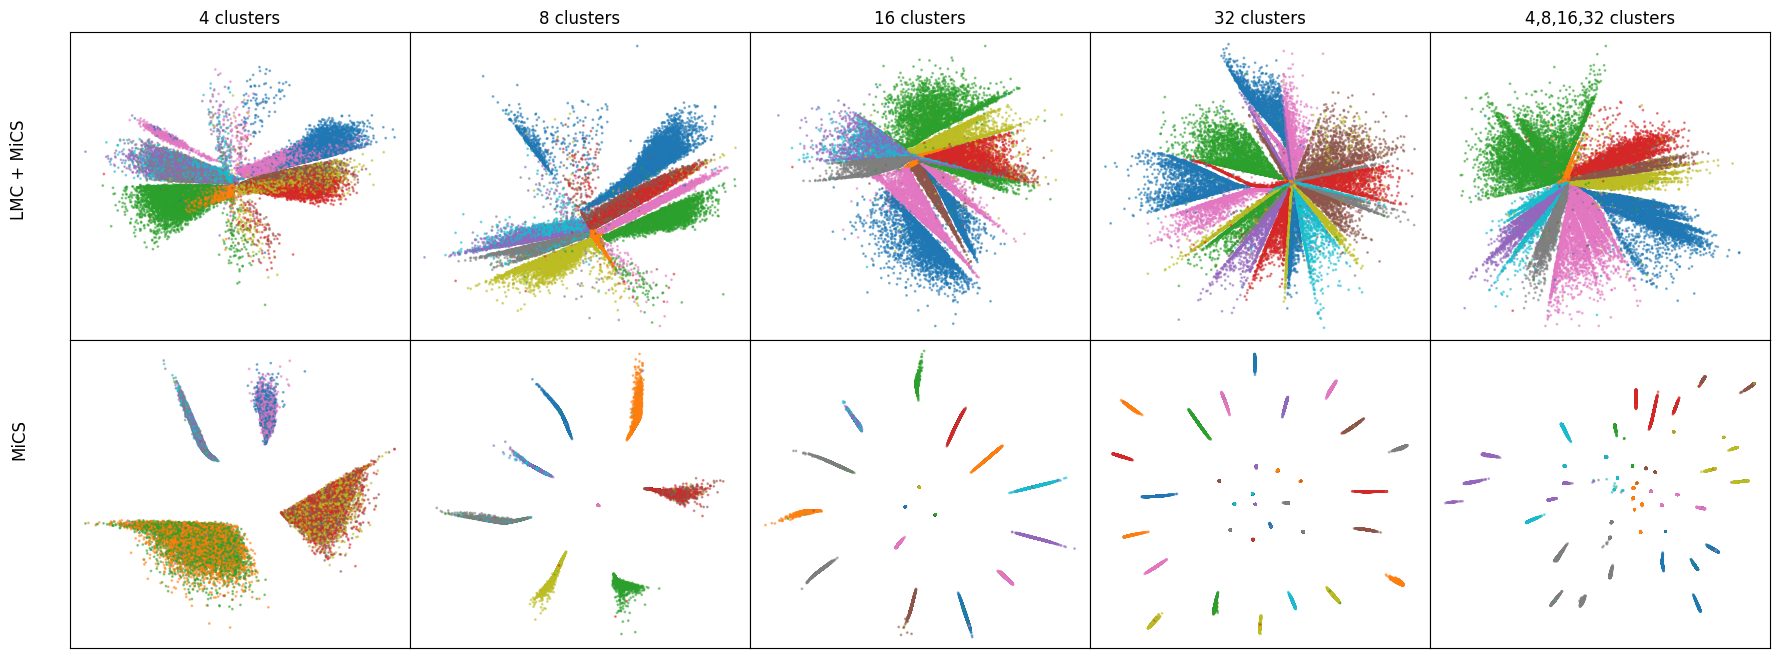

In [17]:
plt.figure(figsize=(20, 8))
titles = ['4 clusters', '8 clusters', '16 clusters', '32 clusters', '4,8,16,32 clusters']

# Add row labels
plt.figtext(0.02, 0.65, 'LMC + MiCS', fontsize=12, rotation=90)
plt.figtext(0.02, 0.35, 'MiCS', fontsize=12, rotation=90)

for idx, (embedding_lmc, embedding, clusters) in enumerate(zip(cluster_embeddings_with_lmc, cluster_embeddings, cluster_sets)):
    plt.subplot(2, 5, idx+1)
    plt.scatter(embedding_lmc[:, 0], embedding_lmc[:, 1], c=y, cmap='tab10', alpha=0.5, s=1)
    plt.title(titles[idx])
    plt.axis('equal')
    plt.xticks([])
    plt.yticks([])
    
    plt.subplot(2, 5, idx+6)
    plt.scatter(embedding[:, 0], embedding[:, 1], c=y, cmap='tab10', alpha=0.5, s=1)
    plt.axis('equal')
    plt.xticks([])
    plt.yticks([])

plt.subplots_adjust(wspace=0, hspace=0, left=0.05)
plt.savefig('mics_comparison.png', dpi=600, bbox_inches='tight')

plt.show()


In [14]:
from sklearn.preprocessing import LabelEncoder
y = LabelEncoder().fit_transform(y)

<Figure size 640x480 with 0 Axes>